In [15]:
!pip install -q tensorflow scikit-learn matplotlib pillow


In [16]:

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#from google.colab import files
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from PIL import Image

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.19.0
Libraries imported successfully!


In [17]:
IMG_SIZE = 128
BATCH_SIZE = 32

epochs_input = input("Enter number of epochs (5–20 recommended): ")

EPOCHS = int(epochs_input) if epochs_input.isdigit() and int(epochs_input) > 0 else 10

mode = input(
    "Enter REAL to upload a dataset or DEMO to test the pipeline: "
).strip().upper()

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Mode:", mode)

Enter number of epochs (5–20 recommended):  10
Enter REAL to upload a dataset or DEMO to test the pipeline:  demo


Image size: 128
Batch size: 32
Epochs: 10
Mode: DEMO


In [18]:
def create_demo_dataset(base_dir="dataset_demo"):
    rng = np.random.default_rng(42)

    for split, count in [("train", 80), ("validation", 20)]:
        for label in ["real", "ai_generated"]:

            folder = os.path.join(base_dir, split, label)
            os.makedirs(folder, exist_ok=True)

            for i in range(count):
                image_path = os.path.join(folder, f"img_{i}.png")

                if os.path.exists(image_path):
                    continue

                image = rng.integers(
                    0, 256,
                    size=(IMG_SIZE, IMG_SIZE, 3),
                    dtype=np.uint8
                )

                plt.imsave(image_path, image)

    return base_dir


def upload_dataset_zip():
    print("Upload your dataset ZIP file.")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No ZIP file uploaded.")

    zip_name = next(iter(uploaded))

    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall("/content")

    dataset_dir = "/content/dataset"

    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(
            "Please ensure the ZIP contains a dataset folder."
        )

    return dataset_dir


if mode == "REAL":
    DATASET_DIR = upload_dataset_zip()
else:
    DATASET_DIR = create_demo_dataset()

print("Dataset location:", DATASET_DIR)

Dataset location: dataset_demo


In [19]:
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Class mapping: {'ai_generated': 0, 'real': 1}


In [20]:
def build_cnn():

    model = models.Sequential([

        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_cnn()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 830,913 (3.17 MB)

 Trainable params: 830,913 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("Starting CNN training...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

print("Training completed successfully!")

Starting CNN training...


C:\Users\Jamal\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4375 - loss: 0.7164 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 651ms/step - accuracy: 0.4875 - loss: 0.7018 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 727ms/step - accuracy: 0.5688 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step - accuracy: 0.5188 - loss: 0.6984 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 637ms/step - accuracy: 0.4938 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 618ms/step - accuracy: 0.5875 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 658ms/step - accuracy: 0.5437 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 640ms/step - accuracy: 0.4625 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0

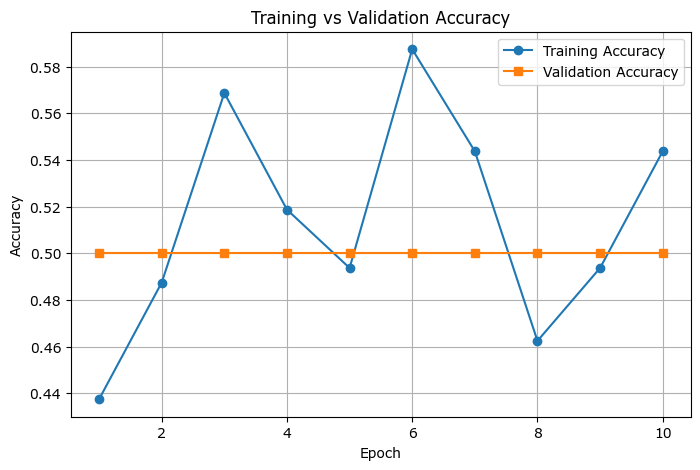

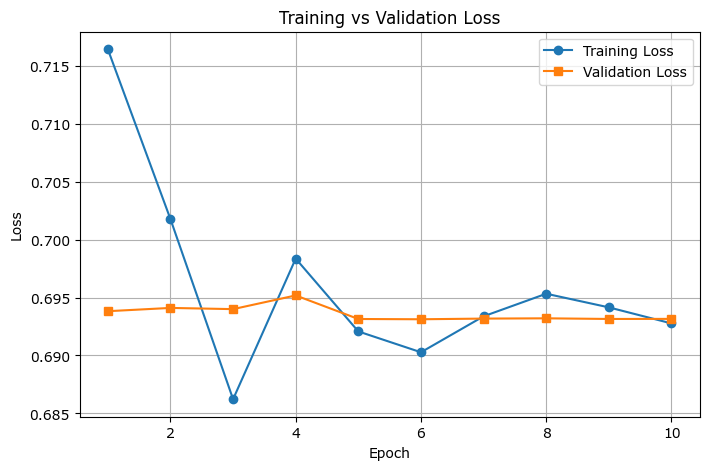

In [22]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
val_generator.reset()

probabilities = model.predict(val_generator)

y_pred = (probabilities > 0.5).astype(int).reshape(-1)

y_true = val_generator.classes

print("Classification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Real", "AI-Generated"],
        zero_division=0
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step
Classification Report:
              precision    recall  f1-score   support

        Real       0.50      1.00      0.67        20
AI-Generated       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



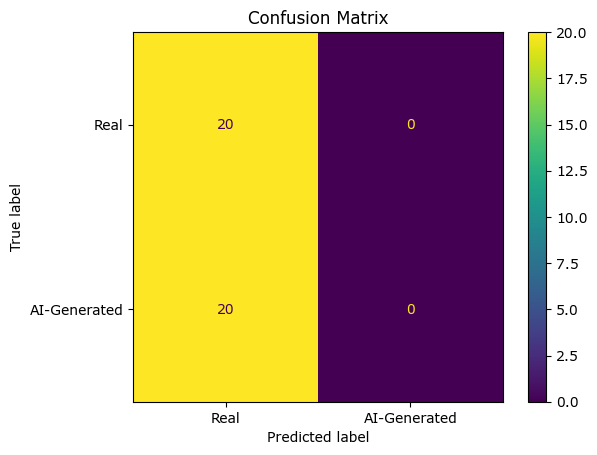

In [24]:
cm = confusion_matrix(y_true, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "AI-Generated"]
)

display.plot(values_format="d")

plt.title("Confusion Matrix")
plt.show()

In [25]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["Real", "AI-Generated"],
    output_dict=True,
    zero_division=0
)

accuracy = report["accuracy"]
precision = report["weighted avg"]["precision"]
recall = report["weighted avg"]["recall"]
f1 = report["weighted avg"]["f1-score"]

print("=" * 45)
print("FINAL MODEL PERFORMANCE")
print("=" * 45)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("=" * 45)

FINAL MODEL PERFORMANCE
Accuracy  : 0.5000 (50.00%)
Precision : 0.2500
Recall    : 0.5000
F1-Score  : 0.3333


Enter image path:  "C:\Users\Jamal\Downloads\Screenshot 2026-09-29 212650.png"


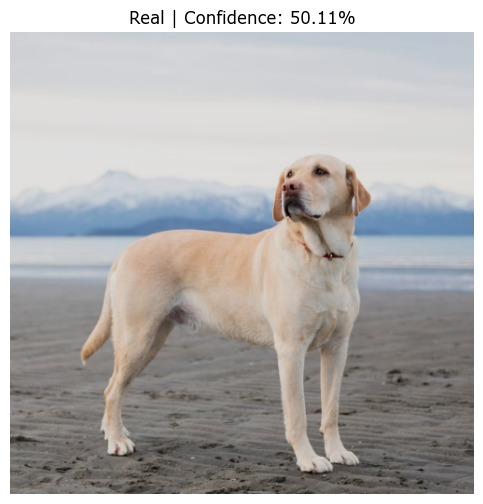

Final Prediction: Real
P(AI-Generated): 0.4989
P(Real): 0.5011
Confidence: 50.11%


In [30]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = input("Enter image path: ").strip().strip('"').strip("'")

if Path(image_path).is_file():

    image = Image.open(image_path).convert("RGB")
    resized_image = image.resize((IMG_SIZE, IMG_SIZE))

    image_array = np.array(resized_image, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probability = float(model.predict(image_array, verbose=0)[0][0])

    if probability >= 0.5:
        prediction = "AI-Generated"
        confidence = probability
    else:
        prediction = "Real"
        confidence = 1 - probability

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{prediction} | Confidence: {confidence * 100:.2f}%")
    plt.show()

    print("Final Prediction:", prediction)
    print(f"P(AI-Generated): {probability:.4f}")
    print(f"P(Real): {1 - probability:.4f}")
    print(f"Confidence: {confidence * 100:.2f}%")

else:
    print("Error: Image file not found.")